In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from pathlib import Path
import re

import matplotlib as mpl

In [11]:
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.size'] = 20
#mpl.rcParams['font.family'] = 'serif'
#mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['axes.linewidth'] = 1.0
mpl.rcParams['grid.linewidth'] = 0.5
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['legend.frameon'] = True
mpl.rcParams['legend.shadow'] = False
mpl.rcParams['legend.edgecolor'] = 'black'
mpl.rcParams['legend.fancybox'] = False
mpl.rcParams["svg.fonttype"] = "none"

In [12]:
# Data from the table
models = ['Beer', 'Crauste', 'Becker', 'Sneyd', 'Boehm', 'Hass', 'Swameye', 'Zheng']
states = [4, 5, 6, 6, 8, 9, 9, 15]

# Condition numbers for each degree
data = {
    #'Bruno':   [3.41e17, 4.29e06, 3.98e05, 3.97e05],
    'Beer':    [4.90e08, 6.50e14, 2.54e20, 3.32e22],
    'Crauste': [1.63e12, 1.31e20, 3.84e28, 7.09e39],
    'Becker':  [1.05e20, 2.03e25, 5.70e26, 1.21e28],
    'Sneyd':   [2.36e23, 4.38e30, 1.83e40, 1.72e47],
    'Boehm':   [1.76e25, 1.77e36, 5.65e43, 4.33e21],
    'Hass':    [3.17e24, 5.57e30, 2.33e34, 8.8e29],
    'Swameye': [2.85e18, 9.71e20, 6.85e20, 1.25e20],
    'Zheng':   [9.23e20, 2.66e22, 6.49e22, 9.80e21]
}

In [13]:
out_path_plots3 = Path("/Users/yuxiangfeng/Desktop/SINDy/Plots/Fig3_final")
font_size = 20

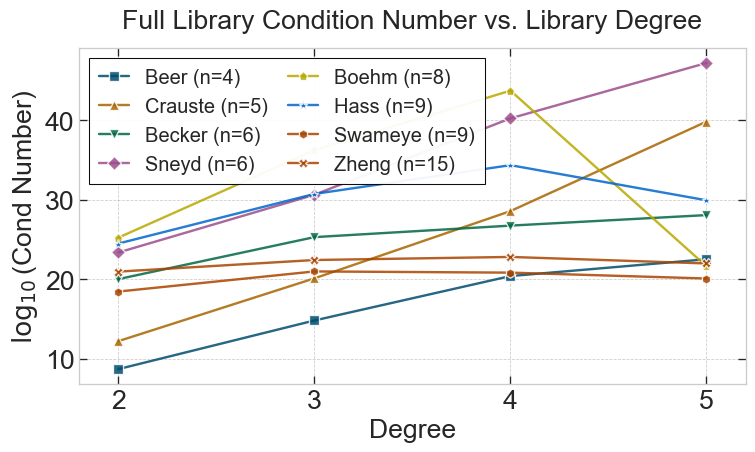

In [21]:
degrees = [2, 3, 4, 5]

# Define colors and markers - colorblind-friendly palette
#colors = ['#0173B2', '#DE8F05', '#029E73', '#CC78BC', '#ECE133', 
         # '#56B4E9', '#D55E00', '#D55E00', '#949494']
    
colors = [
    '#004C6D',  
    '#A86500',  
    '#006644',  
    '#9B4D8C',  
    '#B8A800',  
    '#0066CC',  
    '#AA4400',  
    '#AA4400',  
    '#5E5E5E',  
]

markers = ['s', '^', 'v', 'D', 'p', '*', 'h', 'X']

# Create figure for Plot 1: Degree vs Condition Number
plt.figure(figsize=(8.2677, 5.1181),dpi=96)  

for i, model in enumerate(models):
    log_values = [np.log10(val) for val in data[model]]
    plt.plot(degrees, log_values, 
             marker=markers[i], 
             color=colors[i], 
             label=f'{model} (n={states[i]})',
             linewidth=1.8,
             markersize=7,
             markeredgewidth=1.0,
             markeredgecolor='white',
             alpha=0.85)

plt.xlabel('Degree', fontsize=font_size)
#ax1.set_ylabel(r'$\log_{10}$(Cond)',fontsize=font_size)
plt.ylabel(r'$\log_{10}$(Cond Number)', fontsize=font_size)
plt.title('Full Library Condition Number vs. Library Degree', fontsize=font_size, pad=15)
plt.grid(True, alpha=0.4, linestyle='--', linewidth=0.6, color='gray')
plt.xticks(degrees)
plt.xlim(1.8, 5.2)

# Improve legend
legend = plt.legend(loc='upper left', 
                    frameon=True,
                    framealpha=0.95, 
                    fontsize=15, 
                    ncol=2,
                    columnspacing=1.0,
                    handlelength=1.5,
                    borderpad=0.5,
                    edgecolor='black',
                    facecolor='white')
# Set border line width
legend.get_frame().set_linewidth(0.8)  
legend.get_frame().set_edgecolor('black')  

# Add minor ticks
from matplotlib.ticker import MultipleLocator
ax = plt.gca()
ax.yaxis.set_minor_locator(MultipleLocator(5))
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=6, width=1.0)

plt.tight_layout()
plt.savefig(out_path_plots3 / "Cond_full_degree.svg",
            bbox_inches="tight", pad_inches=0.02)
plt.show()

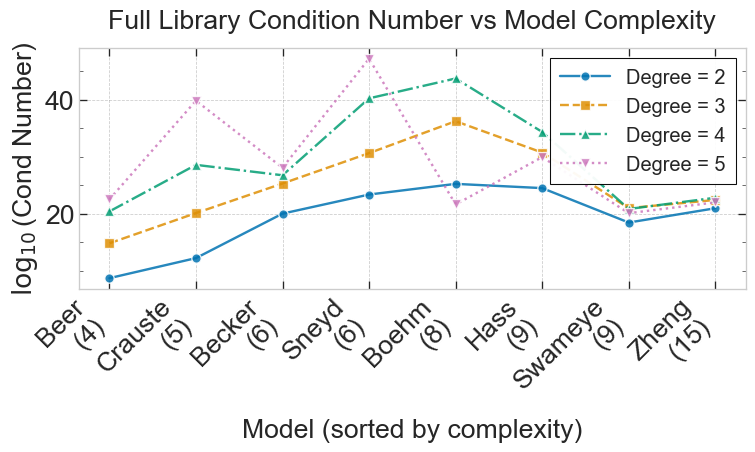

In [23]:
# Define colors for degrees - colorblind-friendly palette
colors_degrees = ['#0173B2', '#DE8F05', '#029E73', '#CC78BC']
markers_degrees = ['o', 's', '^', 'v']

# Sort models by number of states (complexity)
sorted_indices = np.argsort(states)
sorted_models = [models[i] for i in sorted_indices]
sorted_states = [states[i] for i in sorted_indices]

# Create figure for Plot 2: Model Complexity vs Condition Number
plt.figure(figsize=(8.2677, 5.1181),dpi=96)

# Plot data for each degree
line_styles = ['-', '--', '-.', ':']
for deg_idx, degree in enumerate(degrees):
    values_for_degree = []
    for model in sorted_models:
        model_idx = models.index(model)
        values_for_degree.append(np.log10(data[model][deg_idx]))
    
    plt.plot(range(len(sorted_models)), values_for_degree,
             marker=markers_degrees[deg_idx],
             color=colors_degrees[deg_idx],
             label=f'Degree = {degree}',
             linewidth=1.8,
             linestyle=line_styles[deg_idx],
             markersize=7,
             markeredgewidth=1.0,
             markeredgecolor='white',
             alpha=0.85)

# Customize x-axis for model names with states
plt.xticks(range(len(sorted_models)),
           [f'{sorted_models[i]}\n({sorted_states[i]})' 
            for i in range(len(sorted_models))], 
           rotation=45, ha='right', fontsize=font_size)

plt.xlabel('Model (sorted by complexity)', fontsize=font_size)
plt.ylabel(r'$\log_{10}$(Cond Number)', fontsize=font_size)
plt.title('Full Library Condition Number vs Model Complexity', fontsize=font_size,pad=15)
plt.grid(True, alpha=0.4, linestyle='--', linewidth=0.6, color='gray')

# Improve legend
legend = plt.legend(loc='upper right', 
                    frameon=True,
                    framealpha=0.95, 
                    fontsize=15,
                    handlelength=2.5,
                    borderpad=0.5,
                    edgecolor='black',
                    facecolor='white')
# Set border line width
legend.get_frame().set_linewidth(0.8)  
legend.get_frame().set_edgecolor('black')  

# Add minor ticks
from matplotlib.ticker import MultipleLocator
ax = plt.gca()
ax.yaxis.set_minor_locator(MultipleLocator(5))
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=6, width=1.0)
ax.tick_params(which='minor', length=3, width=0.5)

plt.tight_layout()
plt.savefig(out_path_plots3 / "Cond_full_model.svg",
            bbox_inches="tight", pad_inches=0.02)
plt.show()

Part 2

In [16]:
dir = Path("/Users/yuxiangfeng/Desktop/SINDy/Plots/Fig3")
file_path = dir / "Table_fine.xlsx"
df = pd.read_excel(file_path)

degrees = [2, 3, 4, 5]

def parse_cell(cell):
    """
    Parse the string-form list in the cell into an array of floating-point numbers.
    """
    if isinstance(cell, str):
        # Extract all numbers
        nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", cell)
        return np.array([float(x) for x in nums], dtype=float)
    elif isinstance(cell, (list, tuple, np.ndarray)):
        return np.array(cell, dtype=float)
    else:
        return np.array([], dtype=float)

for deg in degrees:
    df[f"{deg}_vals"] = df[deg].apply(parse_cell)

# Compute means and std
mean_data = {}
std_data = {}

for deg in degrees:
    arr_series = df[f"{deg}_vals"]

    mean_series = arr_series.apply(
        lambda a: a.mean() if a.size > 0 else np.nan
    )
    std_series = arr_series.apply(
        lambda a: a.std(ddof=1) if a.size > 1 else np.nan  
    )

    mean_data[deg] = mean_series.values
    std_data[deg] = std_series.values

# Use Model Name as the index and degree as the column
mean_df = pd.DataFrame(mean_data, index=df["Model Name"])
std_df  = pd.DataFrame(std_data,  index=df["Model Name"])

# Model complexity (number of equations)
complexity = df.set_index("Model Name")["Complexity"]

plt.style.use("seaborn-v0_8-whitegrid")  

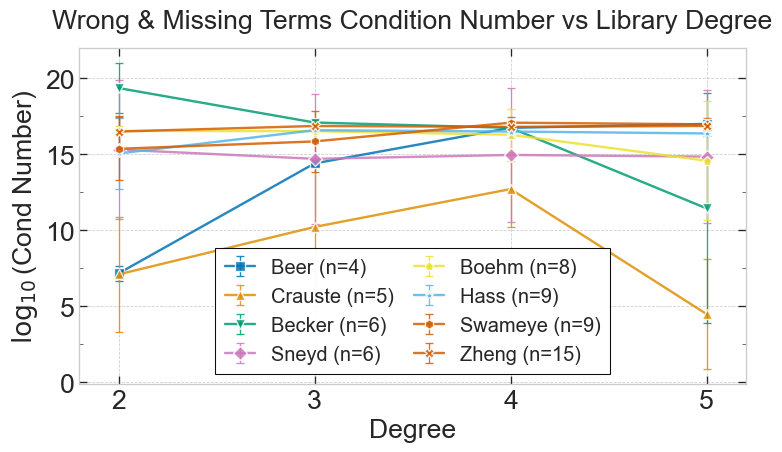

In [ ]:
fig, ax = plt.subplots(figsize=(8.2677, 5.1181), dpi=96)
models_sorted = sorted(mean_df.index, key=lambda m: complexity[m])

for i, model in enumerate(models_sorted):
    y    = mean_df.loc[model, degrees].values
    yerr = std_df.loc[model, degrees].values

    ax.errorbar(
        degrees,
        y,
        yerr=yerr,
        fmt=markers[i % len(markers)] + "-",
        color=colors[i % len(colors)],
        label=f"{model} (n={complexity[model]})",
        linewidth=1.8,
        markersize=7,
        markeredgewidth=1.0,
        markeredgecolor='white',
        capsize=3,
        elinewidth=1.0,
        capthick=1.0,
        alpha=0.85
    )

# Match axis labels from first plot
ax.set_xlabel('Degree', fontsize=font_size)
plt.ylabel(r'$\log_{10}$(Cond Number)', fontsize=font_size)
ax.set_title('Wrong & Missing Terms Condition Number vs Library Degree', fontsize=font_size, pad=15)

# Match grid style from first plot
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.6, color='gray')

ax.set_xticks(degrees)
ax.set_xlim(1.8, 5.2)

legend = ax.legend(loc='best',  
                   frameon=True,         
                   framealpha=0.95,      
                   fontsize=15,          
                   ncol=2,               
                   columnspacing=1.0,    
                   handlelength=1.5,     
                   borderpad=0.5,        
                   edgecolor='black',    
                   facecolor='white',    
                   borderaxespad=0.5)    

# Set border linewidth
legend.get_frame().set_linewidth(0.8)  # Border linewidth
legend.get_frame().set_edgecolor('black')  

# Add minor ticks like first plot
from matplotlib.ticker import MultipleLocator
ax.yaxis.set_minor_locator(MultipleLocator(2.5))
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=6, width=1.0)
ax.tick_params(which='minor', length=3, width=0.5)

fig.tight_layout()
plt.savefig(out_path_plots3 / "wrong_missing_degree.svg",
            bbox_inches="tight", pad_inches=0.02)
plt.show()

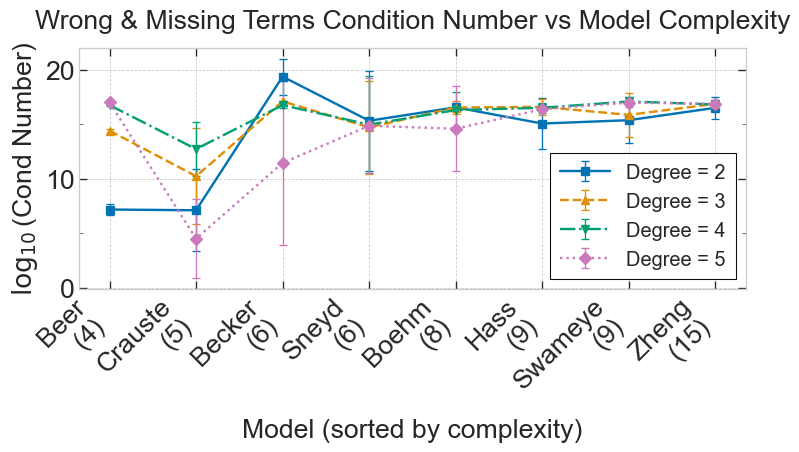

In [ ]:
# axis x = model（(in ascending order of complexity)）
# axis y = log10(condition number)
# Each line represents one degree, with points showing the mean plus standard deviation error bars.

fig, ax = plt.subplots(figsize=(8.2677, 5.1181), dpi=96)

colors = ['#0173B2', '#DE8F05', '#029E73', '#CC78BC', '#ECE133', 
          '#56B4E9', '#D55E00', '#D55E00', '#949494']

# Sort by complexity first
sorted_models = complexity.sort_values().index
x = np.arange(len(sorted_models))

line_styles = ["-", "--", "-.", ":"]

for j, deg in enumerate(degrees):
    y    = mean_df.loc[sorted_models, deg].values
    yerr = std_df.loc[sorted_models, deg].values

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt=markers[j % len(markers)] + line_styles[j % len(line_styles)],
        color=colors[j % len(colors)],
        label=f"Degree = {deg}",
        linewidth=1.8,
        markersize=6,
        capsize=3,
        elinewidth=1.0,
        capthick=1.0,
    )

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{m}\n({complexity[m]})" for m in sorted_models],
    rotation=45,
    ha="right"
)

ax.set_xlabel("Model (sorted by complexity)",fontsize=font_size)
plt.ylabel(r'$\log_{10}$(Cond Number)', fontsize=font_size)
ax.set_title("Wrong & Missing Terms Condition Number vs Model Complexity", fontsize=font_size, pad=15)

ax = plt.gca()
ax.yaxis.set_minor_locator(MultipleLocator(5))
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=6, width=1.0)
ax.tick_params(which='minor', length=3, width=0.5)
plt.grid(True, alpha=0.4, linestyle='--', linewidth=0.6, color='gray')

#ax.legend(frameon=True, framealpha=0.95)
# Improve legend
legend = plt.legend(loc='lower right', 
                    frameon=True,
                    framealpha=0.95, 
                    fontsize=15,
                    handlelength=2.5,
                    borderpad=0.5,
                    edgecolor='black',
                    facecolor='white')
# Set border linewidth
legend.get_frame().set_linewidth(0.8)  # Border linewidth
legend.get_frame().set_edgecolor('black')  

fig.tight_layout()
fig.savefig(out_path_plots3 / "wrong_missing_model.svg",
            bbox_inches="tight", pad_inches=0.02)
plt.show()